Before SMOTE:
 label
0    55011
1    48950
Name: count, dtype: int64
After SMOTE:
 label
0    55011
1    55011
Name: count, dtype: int64
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Confusion Matrix:
 [[23535    42]
 [   37 20942]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     23577
           1       1.00      1.00      1.00     20979

    accuracy                           1.00     44556
   macro avg       1.00      1.00      1.00     44556
weighted avg       1.00      1.00      1.00     44556

Accuracy:  0.9982
Precision: 0.9980
Recall:    0.9982
F1 Score:  0.9981


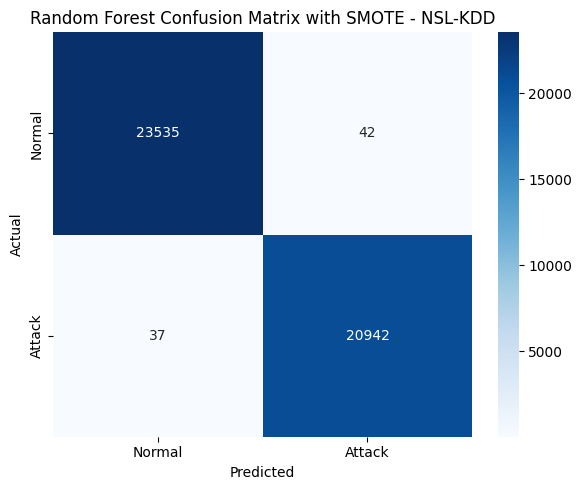

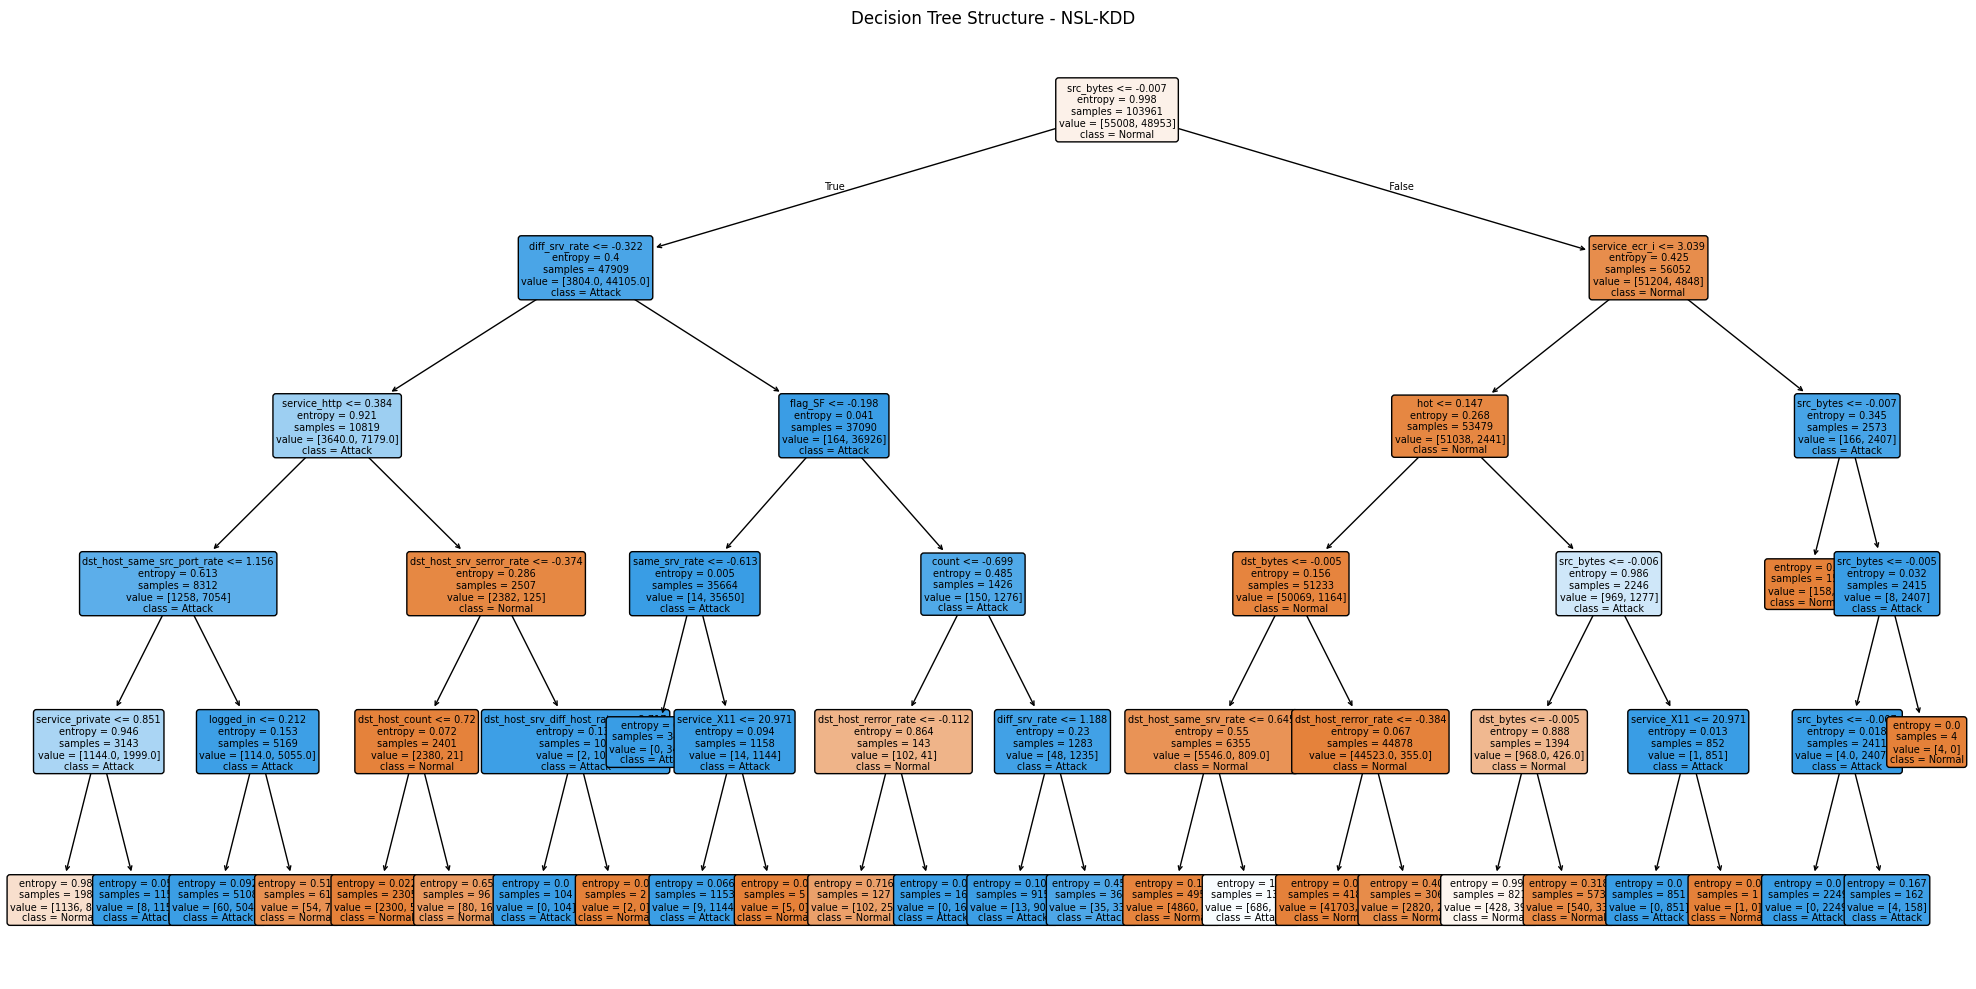

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from imblearn.over_sampling import SMOTE  # <--- added

# === Load and prepare data ===
df_train = pd.read_csv("nslkdd/kdd_train.csv", header=0, low_memory=False)
df_test = pd.read_csv("nslkdd/kdd_test.csv", header=0, low_memory=False)

column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]
df_train.columns = column_names
df_test.columns = column_names
df = pd.concat([df_train, df_test])

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'])

# Encode labels
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Split features and labels
X = df.drop('label', axis=1)
y = df['label']

# Train/test split (stratify keeps class ratio in test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# === Apply SMOTE on training set ===
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())

# === Random Forest with RandomizedSearchCV ===
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train_res, y_train_res)   # <--- train on resampled data

best_rf = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Predict with best model
y_pred = best_rf.predict(X_test)   # <--- test set remains untouched

# === Print metrics ===
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

# === Confusion Matrix Heatmap ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title("Random Forest Confusion Matrix with SMOTE - NSL-KDD")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# === Decision Tree Plot ===
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=['Normal', 'Attack'], filled=True, rounded=True, fontsize=7)
plt.title("Decision Tree Structure - NSL-KDD")
plt.tight_layout()
plt.show()